## Project 2
Classification
10 points total

Program 1
Generate a dataset:
- 2 dimensions - x1, x2
- 4 classes (arbitrary)
- 50 data points per class, 200 total


The standard deviation, shape, and location of the cluster centers are left to your decision.
Divide the data into a training and testing sets in a 80/20 ratio.


Visualise the dataset.
Write and train three multi-class classifiers:
1. Using a combinations of binary perceptrons, with a
    - One-versus-one strategy, or
    - One-versus-rest strategy
2. Using logistic regression. Use the softmax function.

Visualise the accuracy of each classifier based on the test set.
Write a 1-2 sentence comparison of approaches.




Import of required libraries

In [569]:
from typing import Literal, Annotated, Any

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import numpy as np
from numpy import ndarray


Generate dataset - part I

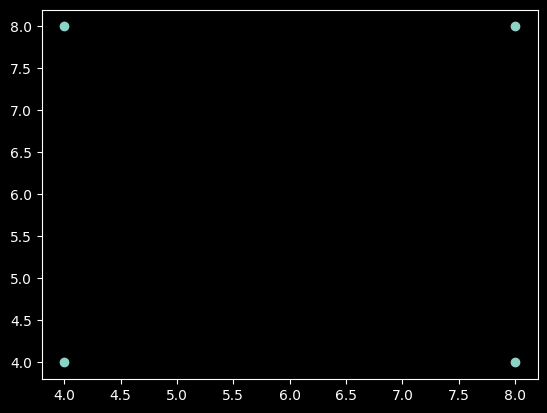

In [570]:
centroids = [(4, 4), (8,4), (4, 8), (8,8)]
# centroids = [(4, 4), (8,4)]

standard_deviation = 0.9

x_centroids = [t[0] for t in centroids]
y_centroids = [t[1] for t in centroids]

plt.scatter([t[0] for t in centroids], [t[1] for t in centroids])

Generate dataset - part II

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


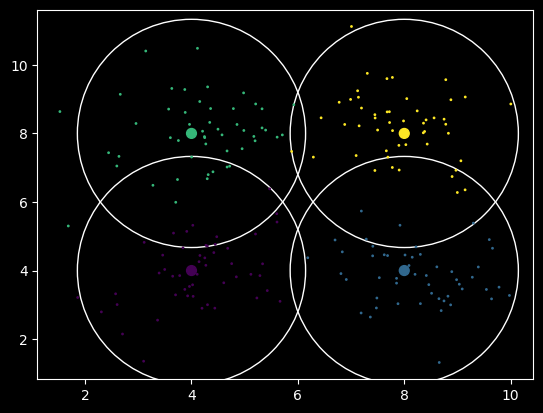

In [571]:
# order between X and Y arrays has to be maintained
# X = features
X = []
# y = labels
y = []

samples_per_class = 50
dimensionality_of_features = 2

for i, centroid in enumerate(centroids):
    samples = np.random.randn(samples_per_class, dimensionality_of_features)
    samples = samples * standard_deviation + centroid
    X.append(samples)
    y.append([i] * samples_per_class)

X = np.concatenate(X)
y = np.concatenate(y)

print(type(X))
print(type(y))

a = ndarray

colors_of_centroids = np.unique(y)
colors_of_samples = y
size_of_centroids_range = standard_deviation * 1000 * 30
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], facecolors='none', edgecolors='white', s=size_of_centroids_range)
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], c=colors_of_centroids, s=50)
plt.scatter(X[:,0], X[:,1], c=colors_of_samples, s=1)

Definition of Perceptron model

In [572]:
class Perceptron:

    def __init__(self, dimensionality, name="perceptron_x", activation_function = lambda x: 1 if x > 0 else 0):
        self.name = name
        # parameters
        self.weights = np.random.rand(dimensionality) * 2 - 1 # weights in range from -1 to 1
        self.bias = np.random.rand()
        self.learning_rate = 0.1
        self.epochs = 20
        self.activation = activation_function

        # metrics
        self.correct_classifications = 0
        self.all_classifications = 0

    def _forward(self, feature: np.ndarray) -> float:
        product = np.dot(feature, self.weights)
        product = product + self.bias
        result = self.activation(product)

        if self.activation == (lambda x: 1 if x > 0 else 0):
            assert result in [0,1], "Perceptron should be binary."

        return result

    def _backwards(self, feature: np.ndarray, error: float):

        self.all_classifications += 1
        self.correct_classifications += abs(abs(error) - 1)

        self.bias += error * self.learning_rate
        for dimension in range(len(self.weights)):
            self.weights[dimension] += feature[dimension] * error * self.learning_rate

    def learn(self, features: np.ndarray, labels: np.ndarray):
        for epoch in range(0,self.epochs):
            for feature, label in zip(features,labels):
                # predict
                predicted_label = self._forward(feature)
                # compute error of prediction
                error = round(label - predicted_label, 5)
                # adjust Perceptron according to erro
                self._backwards(feature, error)
            self.all_classifications = 0
            self.correct_classifications = 0


    def predict(self, features: np.ndarray) -> np.ndarray:
        predicted_labels = [self._forward(feature) for feature in features]
        return np.array(predicted_labels)

Function for plotting perceptron boundries

In [573]:
def plot_perceptron_boundary(ax, perceptron: Perceptron, color: str, label: str, x_limits: tuple[float, float]):
    w_0, w_1 = perceptron.weights

    x_values = np.array(x_limits)
    y_values = -(w_0 * x_values + perceptron.bias) / w_1
    ax.plot(x_values, y_values, color=color, linestyle='--', linewidth=1, alpha=0.8, label=label)

Smoke test of perceptron

In [574]:
def yield_accuracy_of_predictions(p: Perceptron, features_set, labels_set):
    predictions = p.predict(X)
    correct = 0

    for true_label, prediction in zip(y, predictions):
        if true_label == prediction:
            correct += 1

    return str(correct / len(predictions))

test_perceptron = Perceptron(dimensionality=2)

accuracy = yield_accuracy_of_predictions(p=test_perceptron, features_set=X, labels_set=y)
print("accuracy: " + accuracy)
assert (0.20 < float(accuracy) < 0.30), "A single four-class perceptron without any training should have 25% accuracy."

accuracy: 0.25


**experimental strategy** : one-vs-rest binary classifiers with output space {0,1}

Accuracy of One vs Rest Experimental : 0.875


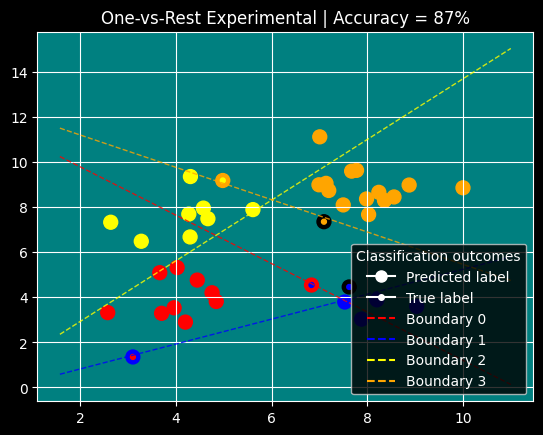

In [575]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

# Perceptron 0
y_0 = np.array([1 if e == 0 else 0 for e in labels_train_set])
perceptron_0 = Perceptron(dimensionality=2, name="perceptron_0")
perceptron_0.learn(features_train_set,y_0)
# Perceptron 1
y_1 = np.array([1 if e == 1 else 0 for e in labels_train_set])
perceptron_1 = Perceptron(dimensionality=2, name="perceptron_1")
perceptron_1.learn(features_train_set,y_1)
# Perceptron 2
y_2 = np.array([1 if e == 2 else 0 for e in labels_train_set])
perceptron_2 = Perceptron(dimensionality=2, name="perceptron_2")
perceptron_2.learn(features_train_set,y_2)
# Perceptron 3
y_3 = np.array([1 if e == 3 else 0 for e in labels_train_set])
perceptron_3 = Perceptron(dimensionality=2, name="perceptron_3")
perceptron_3.learn(features_train_set,y_3)


def one_vs_rest_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []
    perceptron_label_dict = { perceptron_0: 0, perceptron_1: 1, perceptron_2: 2, perceptron_3: 3}

    for feature in features:
        predicted_l = -1
        owner = "Nobody"
        for perceptron in perceptron_label_dict:
            if perceptron.predict(np.array([feature])) == 1:
                predicted_l = perceptron_label_dict.get(perceptron)
                owner = perceptron.name

        predicted_labels.append(predicted_l)
    return predicted_labels

predicted_labels_list = one_vs_rest_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)
print("Accuracy of One vs Rest Experimental : " + str(accuracy))

colors_labels_map = {-1: 'black', 0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0, 'red', 'Boundary 0', x_limits)
plot_perceptron_boundary(ax, perceptron_1, 'blue', 'Boundary 1', x_limits)
plot_perceptron_boundary(ax, perceptron_2, 'yellow', 'Boundary 2', x_limits)
plot_perceptron_boundary(ax, perceptron_3, 'orange', 'Boundary 3', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-Rest Experimental | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 1'),
      Line2D([0], [0], color='yellow', linestyle='--', label='Boundary 2'),
      Line2D([0], [0], color='orange', linestyle='--', label='Boundary 3')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

**strategy 1b**: one-vs-rest binary classifiers with output space [0, 1]

Accuracy of One vs Rest : 0.925


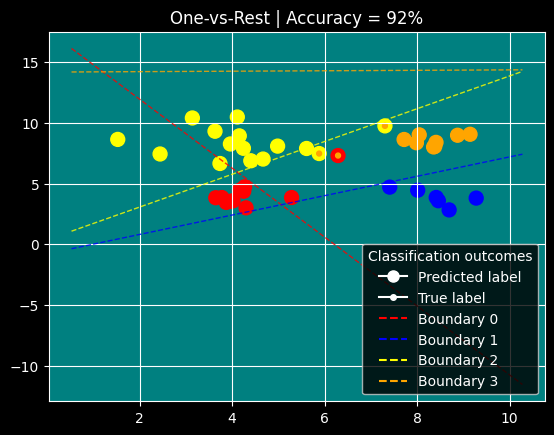

In [576]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

sigmoid_function = lambda x: 1 / (1 + np.exp(-x))

# Perceptron 0
y_0 = np.array([1 if e == 0 else 0 for e in labels_train_set])
perceptron_0 = Perceptron(dimensionality=2, name="perceptron_0", activation_function=sigmoid_function)
perceptron_0.learn(features_train_set,y_0)
# Perceptron 1
y_1 = np.array([1 if e == 1 else 0 for e in labels_train_set])
perceptron_1 = Perceptron(dimensionality=2, name="perceptron_1", activation_function=sigmoid_function)
perceptron_1.learn(features_train_set,y_1)
# Perceptron 2
y_2 = np.array([1 if e == 2 else 0 for e in labels_train_set])
perceptron_2 = Perceptron(dimensionality=2, name="perceptron_2", activation_function=sigmoid_function)
perceptron_2.learn(features_train_set,y_2)
# Perceptron 3
y_3 = np.array([1 if e == 3 else 0 for e in labels_train_set])
perceptron_3 = Perceptron(dimensionality=2, name="perceptron_3", activation_function=sigmoid_function)
perceptron_3.learn(features_train_set,y_3)


def one_vs_rest_classification(features_set: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []
    perceptron_label_dict = { perceptron_0: 0, perceptron_1: 1, perceptron_2: 2, perceptron_3: 3}

    for features in features_set:
        predicted_l = -1
        owner = "Nobody"
        current_max = -1
        for perceptron in perceptron_label_dict:
            degree_of_confidence = perceptron.predict(np.array([features]))
            if degree_of_confidence > current_max:
                current_max = degree_of_confidence
                predicted_l = perceptron_label_dict.get(perceptron)
                owner = perceptron.name

        predicted_labels.append(predicted_l)
    return predicted_labels

predicted_labels_list = one_vs_rest_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)

print("Accuracy of One vs Rest : " + str(accuracy))

colors_labels_map = {-1: 'black', 0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}


fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0, 'red', 'Boundary 0', x_limits)
plot_perceptron_boundary(ax, perceptron_1, 'blue', 'Boundary 1', x_limits)
plot_perceptron_boundary(ax, perceptron_2, 'yellow', 'Boundary 2', x_limits)
plot_perceptron_boundary(ax, perceptron_3, 'orange', 'Boundary 3', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-Rest | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 1'),
      Line2D([0], [0], color='yellow', linestyle='--', label='Boundary 2'),
      Line2D([0], [0], color='orange', linestyle='--', label='Boundary 3')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

One-vs-Rest Performance **Analysis**:

The One-vs-Rest strategy performs well in terms of average accuracy. This approach, however, comes at a training cost. As new classes are added to the dataset, the number of perceptrons that must be trained scales linearly.

The described approach works effectively only after changing the output space from binary to continuous. With a binary output space, one must accept the introduction of an artificial “unknown” class, as it creates the possibility that all perceptrons will conclude that a given sample does not belong to any of them. This variation was tested in the experiment above.

Transitioning to a continuous output space resolves this issue, because the question is no longer whether a sample belongs to a given class in strictly binary terms, but rather which perceptron is the most confident that the sample belongs to its class.


**strategy 1a**: one-vs-one classifier with output space {0,1}

Accuracy of One vs One : 0.925


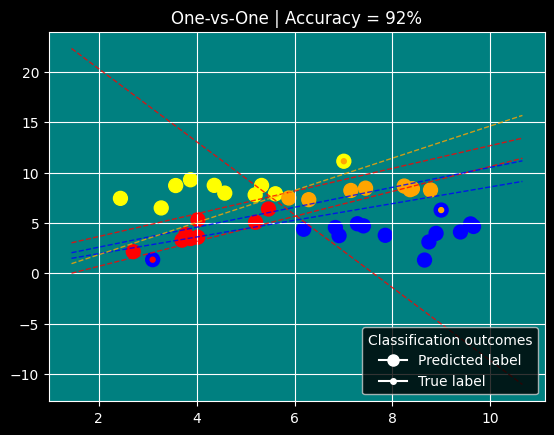

In [581]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

def prepare_train_sets_for_one_vs_one(original_features_set, original_labels_set, label_a: int, label_b: int) -> (np.ndarray, np.ndarray):
    labels_train_set_a_vs_b = []
    features_train_set_a_vs_b = []
    for features, label in zip(original_features_set, original_labels_set):
        if label == label_a or label == label_b:
            labels_train_set_a_vs_b.append(label)
            features_train_set_a_vs_b.append(features)

    labels_train_set_a_vs_b = [1 if label == label_a else 0 for label in labels_train_set_a_vs_b]
    return np.array(labels_train_set_a_vs_b), np.array(features_train_set_a_vs_b)[:,]


# Perceptron 0_vs_1
y_0_vs_1, train_set_0_vs_1 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 0, 1)

perceptron_0_vs_1 = Perceptron(dimensionality=2, name="perceptron_0_vs_1")
perceptron_0_vs_1.learn(train_set_0_vs_1,y_0_vs_1)

# Perceptron 0_vs_2
y_0_vs_2, train_set_0_vs_2 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 0, 2)

perceptron_0_vs_2 = Perceptron(dimensionality=2, name="perceptron_0_vs_2")
perceptron_0_vs_2.learn(train_set_0_vs_2,y_0_vs_2)

# Perceptron 0_vs_3
y_0_vs_3, train_set_0_vs_3 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 0, 3)

perceptron_0_vs_3 = Perceptron(dimensionality=2, name="perceptron_0_vs_3")
perceptron_0_vs_3.learn(train_set_0_vs_3,y_0_vs_3)

# Perceptron 1_vs_2
y_1_vs_2, train_set_1_vs_2 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 1, 2)

perceptron_1_vs_2 = Perceptron(dimensionality=2, name="perceptron_1_vs_2")
perceptron_1_vs_2.learn(train_set_1_vs_2,y_1_vs_2)

# Perceptron 1_vs_3
y_1_vs_3, train_set_1_vs_3 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 1, 3)

perceptron_1_vs_3 = Perceptron(dimensionality=2, name="perceptron_1_vs_3")
perceptron_1_vs_3.learn(train_set_1_vs_3,y_1_vs_3)

# Perceptron 2_vs_3
y_2_vs_3, train_set_2_vs_3 = prepare_train_sets_for_one_vs_one(features_train_set, labels_train_set, 2, 3)

perceptron_2_vs_3 = Perceptron(dimensionality=2, name="perceptron_2_vs_3")
perceptron_2_vs_3.learn(train_set_2_vs_3,y_2_vs_3)


def vote(votes: dict, perceptron: Perceptron, features, label_a: int, label_b: int):
    result = perceptron.predict(np.array([features]))
    if result == 1:
        votes[label_a] += 1
    else:
        votes[label_b] += 1

def max_by_dict_value(dictionary: dict[Any,int]) -> Any:
    current_max_val: int = -1
    associated_key = None

    for key, val in dictionary.items():
        if val > current_max_val:
            current_max_val = val
            associated_key = key

    return associated_key

def one_vs_one_classification(features_set: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []

    for features in features_set:
        votes: dict = {0: 0, 1:0, 2:0, 3:0}
        vote(votes, perceptron_0_vs_1, features, 0, 1)
        vote(votes, perceptron_0_vs_2, features, 0, 2)
        vote(votes, perceptron_0_vs_3, features, 0, 3)
        vote(votes, perceptron_1_vs_2, features, 1, 2)
        vote(votes, perceptron_1_vs_3, features, 1, 3)
        vote(votes, perceptron_2_vs_3, features, 2, 3)

        label_with_max_votes = max_by_dict_value(dictionary=votes)
        predicted_labels.append(label_with_max_votes)

    return predicted_labels

predicted_labels_list = one_vs_one_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)
print("Accuracy of One vs One : " + str(accuracy))

colors_labels_map = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0_vs_1, 'red', 'Boundary 0 vs 1', x_limits)
plot_perceptron_boundary(ax, perceptron_0_vs_2, 'red', 'Boundary 0 vs 2', x_limits)
plot_perceptron_boundary(ax, perceptron_0_vs_3, 'red', 'Boundary 0 vs 3', x_limits)
plot_perceptron_boundary(ax, perceptron_1_vs_2, 'blue', 'Boundary 1 vs 2', x_limits)
plot_perceptron_boundary(ax, perceptron_1_vs_3, 'blue', 'Boundary 1 vs 3', x_limits)
plot_perceptron_boundary(ax, perceptron_2_vs_3, 'orange', 'Boundary 2 vs 3', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-One | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8)
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

One-vs-One Performance Analysis:

For the four-class problem considered here, the One-vs-One strategy achieves very strong accuracy, on average outperforming the One-vs-Rest approach. This advantage, however, comes at the cost of training complexity. As the number of classes increases, the number of required perceptrons grows quadratically - specifically, for n distinct classes, the strategy requires n(n − 1) / 2 binary classifiers.

**experimental strategy** : custom binary output code classifier

Binary Accuracy of Output code : 0.625


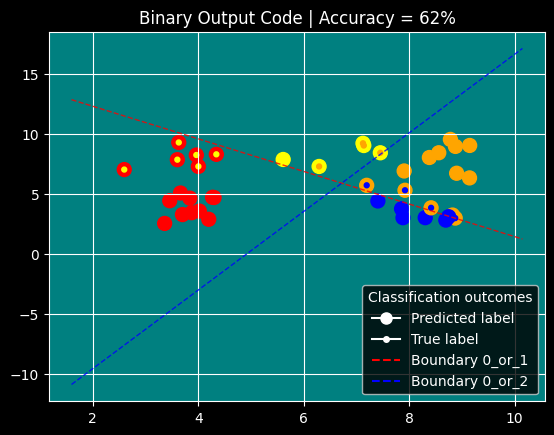

In [578]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

# Perceptron 0_or_1
y_0_or_1 = np.array([1 if e == 0 or e == 0 else 0 for e in labels_train_set])
perceptron_0_or_1 = Perceptron(dimensionality=2, name="perceptron_0_or_1")
perceptron_0_or_1.learn(features_train_set,y_0_or_1)

# Perceptron 0_or_2
y_0_or_2 = np.array([1 if e == 0 or e == 2 else 0 for e in labels_train_set])
perceptron_0_or_2 = Perceptron(dimensionality=2, name="perceptron_0_or_2")
perceptron_0_or_2.learn(features_train_set,y_0_or_2)


def one_vs_one_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []

    for feature in features:
        is_0_or_1: bool = True if 1 == perceptron_0_or_1.predict(np.array([feature])) else False
        is_0_or_2: bool = True if 1 == perceptron_0_or_2.predict(np.array([feature])) else False

        if is_0_or_1:
            if is_0_or_2:
                precited_l = 0
            else:
                precited_l = 1
        else:
            if is_0_or_2:
                precited_l = 2
            else:
                precited_l = 3

        predicted_labels.append(precited_l)

    return predicted_labels

predicted_labels_list = one_vs_one_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)

print("Binary Accuracy of Output code : " + str(accuracy))

colors_labels_map = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0_or_1, 'red', 'Boundary 0_or_1', x_limits)
plot_perceptron_boundary(ax, perceptron_0_or_2, 'blue', 'Boundary 0_or_2', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("Binary Output Code | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0_or_1'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 0_or_2')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

Binary Output Code Classifier **Analysis**:

The binary output code strategy is a custom experimental approach to the multiclass classification problem. For the 4-class task considered here, its average accuracy is approximately 30% lower than that of established strategies such as One-vs-One and One-vs-Rest. Its training cost, however, is twice as low, as it requires only two perceptrons instead of four or more.

In principle, this strategy aims to reduce the number of required perceptrons to a value proportional to the base-2 logarithm of the number of classes. Its prediction procedure resembles binary search: at each step, one decision eliminates roughly half of the remaining candidate classes, until a single class label can be assigned.

Definition of Logistic regression model - _incomplete_

In [579]:
Probability = Annotated[float, "value in [0, 1]"]

class LogisticRegression:

    def __init__(self, dimensionality=2):
        self.weights = np.random.rand(dimensionality)

    def predict(self, features: np.ndarray) -> Probability:
        return self._activate(features)

    def learn(self, features_set, labels_set: np.ndarray[Literal[0,1]]):
        summed_confidence = 0
        for features, label in zip(features_set, labels_set):
            if label == 1:
                prediction_probability = self._activate(features)
            else:
                prediction_probability = 1 - self._activate(features)
            summed_confidence += prediction_probability

        print(summed_confidence)

    def _activate(self, features: np.ndarray) -> Probability:
        product = np.dot(self.weights, features)
        result = 1 / (1 + np.exp(-product))
        assert 0 <= result <= 1, "Probability has to range between 0 and 1"
        return result


classification using logistic regression with softmax - _incomplete_

42.437025957382005


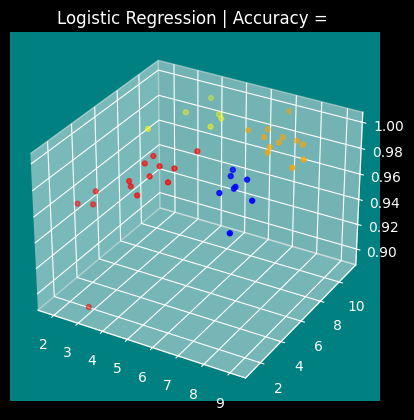

In [580]:
logistic_regression = LogisticRegression(2)

features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

logistic_regression.learn(features_set=features_train_set, labels_set=labels_train_set)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

colors_labels_map = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

probabilities: list[Probability] = [logistic_regression.predict(np.array([features[0], features[1]])) for features in features_test_set]

scatter_true_labels = ax.scatter(
    features_test_set[:,0],
    features_test_set[:,1],
    probabilities,
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("Logistic Regression | Accuracy = ")

plt.show()